ref: https://cellcharter.readthedocs.io/en/latest/notebooks/cosmx_human_nsclc.html#cellcharter-s-spatial-clustering

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os

import cellcharter

/home/kk837/.conda/envs/cellcharter_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/home/kk837/.conda/envs/cellcharter_env/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/kk837/.conda/envs/cellcharter_env/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/kk837/.conda/envs/cellcharter_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import squidpy as sq

In [3]:
import session_info
session_info.show()

In [4]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

In [5]:
sc.settings.set_figure_params(dpi=80)

# Variables

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
path_adata = f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad' # use the object which contains all the qualified cells
latent_space = 'scVI_latent_n-layers-3'
embedding_basis = 'X_umap_scVI_n-layers-3'
library_key='section_ID'

In [7]:
from datetime import date
today = date.today()
print(today)

2026-02-17


In [8]:
os.makedirs(f'{data_object_dir}/cellcharter_autok',exist_ok=True)

# Read in adata

In [9]:
adata = sc.read_h5ad(path_adata)
adata

AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'scVI_latent_n-layers-3_leiden_0.2', 'scVI_latent_n-layers-3_leiden_0.3', 'scVI_latent_n-layers-3_leiden_0.4', 'scVI_latent_n-layers-3_leiden_0.5', 'scVI_latent_n-layers-3_leiden_0.8', 'scVI_latent_n-layers-3_leiden_1.0', 'scVI_latent_n-layers-3_leiden_1.5', 'scVI_latent_n-layers-3_leiden_2.0', 'scVI_latent_n-layers-3_leiden_3.0', 'scVI_latent_n-layers-3_leiden_4.0', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-sc

In [10]:
adata.X.data[:5]

array([1., 1., 1., 1., 1.], dtype=float32)

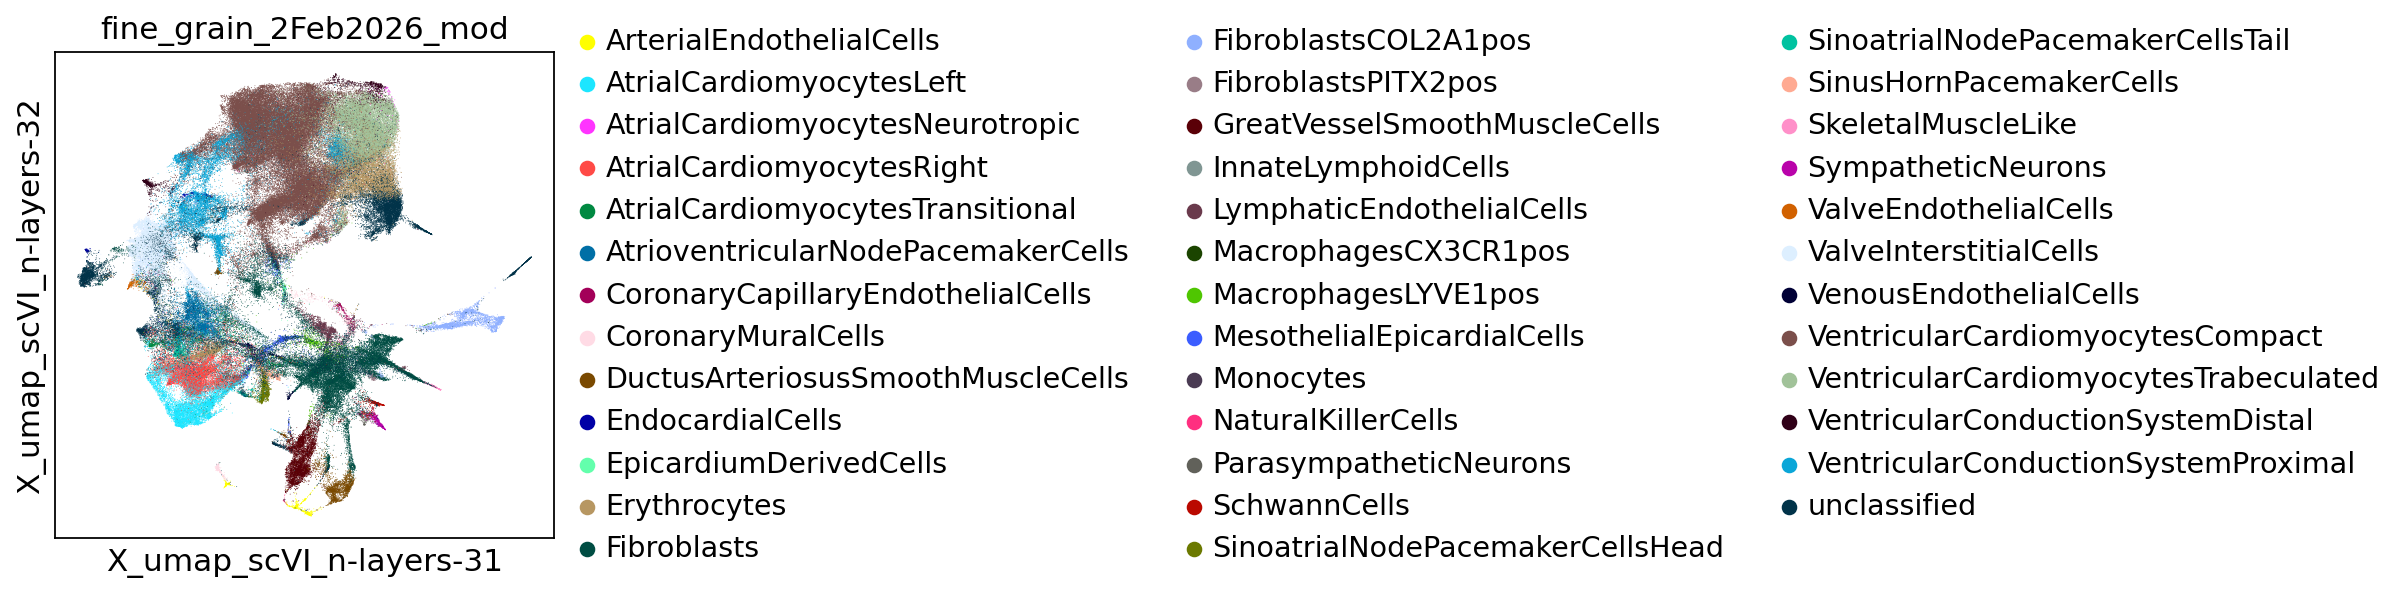

In [11]:
sc.pl.embedding(adata,basis=embedding_basis,color='fine_grain_2Feb2026_mod')

In [12]:
# remove unclassified cells
# adata = adata[adata.obs['fine_grain_8Dec2024'].isin(['unassigned','unclassified'])==False]
# adata.shape

# Log-normalise

In [13]:
# log-normalise the count
sc.pp.filter_genes(adata, min_counts=3)
sc.pp.normalize_total(adata,target_sum=1e4)
sc.pp.log1p(adata)
adata.X.data[:5]

array([1.8897898, 1.8897898, 1.8897898, 1.8897898, 1.8897898],
      dtype=float32)

# CellCharter’s spatial clustering

In [14]:
%%time
sq.gr.spatial_neighbors(adata, spatial_key='spatial',
                        library_key=library_key, coord_type='generic', delaunay=True, percentile=99)

CPU times: user 43.9 s, sys: 328 ms, total: 44.2 s
Wall time: 44.3 s


In [15]:
%%time
# the Delaunay triangulation has the drawback of generating connections between distant cells.
# We remove this long links using CellCharter’s gr.remove_long_links function.
cellcharter.gr.remove_long_links(adata)

CPU times: user 44.7 ms, sys: 1.84 ms, total: 46.5 ms
Wall time: 45.6 ms


### n_layers: 01 ###


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:02<00:08,  2.12s/it]

 40%|████      | 2/5 [00:02<00:02,  1.01it/s]

 60%|██████    | 3/5 [00:02<00:01,  1.34it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


SLURM auto-requeueing enabled. Setting signal handlers.


100%|██████████| 18/18 [03:13<00:00, 14.47s/it]

100%|██████████| 18/18 [03:13<00:00, 10.77s/it]

CPU times: user 1h 28min 14s, sys: 31 s, total: 1h 28min 45s
Wall time: 1h 16min 11s


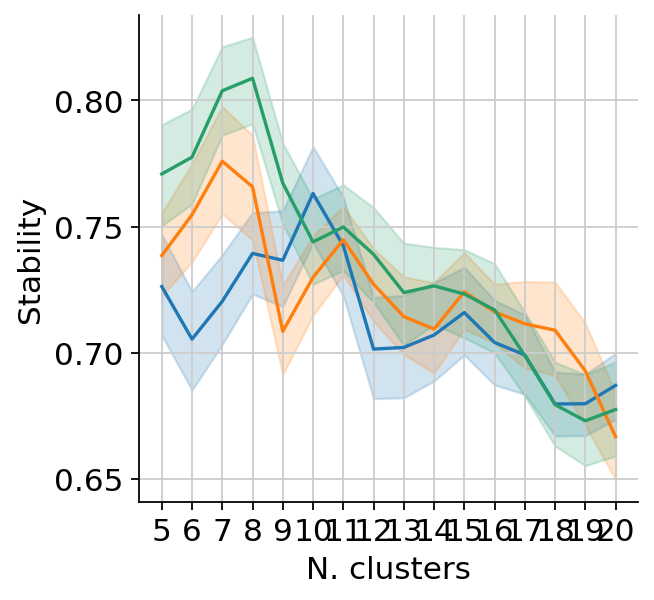

In [16]:
%%time
# the neighborhood aggregation, that incorporates the features of a cell’s environment (i.e. neighbors) into the features of the cell itself.
# It consists of concatenating the features of every cell with the features aggregated from neighbors ad increasing layers from the considered cell, up to a certain layer n_layers.

# argument - n_layers
## Which neighborhood layers to aggregate from.
## If :class:`int`, the output vector includes the cells' features and the aggregated features of the neighbors until the layer at distance ``n_layers``, i.e. cells | 1-hop neighbors | ... | ``n_layers``-hop.
## If :class:`list`, every element corresponds to the distances at which the neighbors' features will be aggregated and concatenated. For example, [0, 1, 3] corresponds to cells|1-hop neighbors|3-hop neighbors.

# Aggregation functions are used to obtain a single feature vector from the vectors of multiple neighbors, with the default being the mean function.

# In this case we use 3 layers of neighbors, so we obtain, for each cell, a feature vector of length 40. That is the cell’s reduced vector size from scVI (10) plus the 3 aggregated vectors of length 10 each, from the 3 layers of neighbors.

for n_layers in [
                 # [1],[1,2],[1,2,3], # doesn't contain own
                 [0,1],[0,1,2],[0,1,2,3] # does contain own
                ]:
    nlayers_str = ''.join([str(x) for x in n_layers])
    print(f'### n_layers: {nlayers_str} ###')
    cellcharter.gr.aggregate_neighbors(adata, n_layers=n_layers, use_rep=latent_space, 
                                       out_key='X_cellcharter', sample_key=library_key)
    
    autok = cellcharter.tl.ClusterAutoK(
        n_clusters=(5,20), 
        max_runs=10,
        convergence_tol=0.001
    )
    autok.fit(adata, use_rep='X_cellcharter')
    cellcharter.pl.autok_stability(autok)
    
    # save autok object
    utils.save_pkl(autok,
                   f'{data_object_dir}/cellcharter_autok/autok_pre-tacco_nlayers-{nlayers_str}_{today}.pkl')
    del autok
    del adata.obsm['X_cellcharter']